<div align="center">

# Blind Challenge 
### (Corso di Astrofisica computazionale Laurea magistrale)

</div>

In questa **blind challenge** abbiamo ricostruito l’analisi BAO condotta da DESI partendo esclusivamente da un insieme di punti isotropici senza alcuna informazione aggiuntiva sui parametri cosmologici reali. Unica informazione è data da una **cosmologia fiduciale di riferimento**, per la quale è stato fissato il **sound horizon**  $r_d$. Nel calcolo di tutte le dilatazioni $\alpha(z)$ abbiamo utilizzato lo stesso valore $r_d^{\rm fid}$ sia per la cosmologia di riferimento sia per ogni modello testato. Per questo piccolo programma, avendo a disposizione soltanto quattro misure BAO, si è deciso di limitare l’analisi al modello **ΛCDM**, poiché i pochi dati a disposizione non erano sufficienti per vincolare in modo significativo modelli con più parametri (wCDM, $w_0 w_a$ CDM, ΛCDM curvo).  
 



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.cosmology import LambdaCDM, wCDM, w0waCDM
from scipy.constants import c
import emcee, corner 
import sys
sys.path.append("../")    

In [2]:
from pyACC.cosmology.distances import Distances

In [3]:
C_KMS = c / 1000.0  
fid_cosmo = LambdaCDM(H0=67.0, Om0=0.27, Ode0=1-0.27)
r_d_fid   = 147.05 

In [4]:
df = pd.read_csv("bao_data_finale2.csv")
mask = df["alpha_iso"].notna() & df["alpha_iso_err"].notna()
df = df.loc[mask].reset_index(drop=True)

z_data      = df["z"].to_numpy()
alpha_data  = df["alpha_iso"].to_numpy()
alpha_sigma = df["alpha_iso_err"].to_numpy()

print(f"→ Caricati {len(z_data)} punti da 'bao_data.csv'")
#print("Prime 5:")
#for i in range(min(5, len(z_data))):
    #print(f" z={z_data[i]:.3f}, α_obs={alpha_data[i]:.4f} ± {alpha_sigma[i]:.4f}")

C_KMS     = 299792.458
r_d_model = 147.05  

→ Caricati 4 punti da 'bao_data.csv'


Abbiamo definito la funzione teorica di dilatazione isotropica come  
$$
\alpha_{\rm iso}(z;\theta) \;=\;
\frac{\bigl[D_V(z;\,H_0,\Omega_m)/r_d\bigr]}
     {\bigl[D_V^{\rm fid}(z)/r_d^{\rm fid}\bigr]},
$$  
dove $D_V(z)$ è calcolato tramite Astropy per ogni $z$ in ingresso. La likelihood, sotto l’ipotesi di errori gaussiani indipendenti, si esprime come  
$$
\ln \mathcal{L}(D\mid\theta)
= -\frac{1}{2}\sum_i
  \frac{\bigl[\alpha_{\rm iso}(z_i;\theta)-\alpha_{\rm data}(z_i)\bigr]^2}
       {\sigma_i^2}
= -\tfrac12\,\chi^2(\theta).
$$  
Il prior sulle coppie $(H_0,\Omega_m)$ è uniforme “a scatola”:  
$$
\pi(\theta)=1\quad\text{se }40 < H_0 < 100\ \mathrm{km\,s^{-1}Mpc^{-1}}
\text{ e }0.05<\Omega_m<0.60,
\quad
\pi(\theta)=0\text{ altrimenti},
$$  
per cui  
$$
\ln \pi(\theta)=0\quad\text{se }\theta\ \text{nel box},\quad
\ln \pi(\theta)=-\infty\quad\text{altrimenti}.
$$  


In [5]:
def dv_model(z, cosmo):
    Dc = cosmo.comoving_distance(z).value
    H  = cosmo.H(z).value
    return ((C_KMS * z * Dc**2) / H)**(1/3)

def dv_rd_model(z, cosmo):
    return dv_model(z, cosmo) / r_d_model

def build_cosmo(theta):
    H0, Om0 = theta
    return LambdaCDM(H0=H0, Om0=Om0, Ode0=1-Om0)

fid_theta = (67.4, 0.315)
fid_cosmo = build_cosmo(fid_theta)

def alpha_model(theta, z):
    cosmo = build_cosmo(theta)
    num   = dv_rd_model(z, cosmo)
    den   = dv_rd_model(z, fid_cosmo)
    return num/den

def ln_prior(theta):
    H0, Om0 = theta
    if 40 < H0 < 100 and 0.05 < Om0 < 0.6:
        return 0.0
    return -np.inf

def ln_likelihood(theta):
    model = alpha_model(theta, z_data)
    return -0.5 * np.sum(((alpha_data - model)/alpha_sigma)**2)

def ln_posterior(theta):
    lp = ln_prior(theta)
    return lp + ln_likelihood(theta) if np.isfinite(lp) else -np.inf


### Esecuzione della catena

Si è eseguita la catena MCMC utilizzando l’algoritmo affine-invariant ensemble sampler di **emcee** e, prima di interpretare i risultati, è stata condotta una fase diagnostica in cui sono stati stimati il tempo di autocorrelazione integrato $\tau$, il numero di campioni indipendenti effettivi $N_{\rm eff}$, e la frazione di accettazione, al fine di verificare la convergenza e valutare eventuali necessità di proseguire il run o di applicare un thinning aggiuntivo.  


In [6]:
ndim   = 2
nwalk  = 32
nsteps = 5000
burn   = 2000

rng = np.random.default_rng(42)
p0 = rng.uniform(low=[40, 0.05], high=[100, 0.6], size=(nwalk, ndim))
sampler = emcee.EnsembleSampler(nwalk, ndim, ln_posterior)
sampler.run_mcmc(p0, nsteps, progress=True)
flat_chain = sampler.get_chain(discard=burn, flat=True)


100%|██████████| 5000/5000 [02:46<00:00, 29.94it/s]


### Diagnostica

In [7]:
try:
    tau = sampler.get_autocorr_time(tol=0.05)
except emcee.autocorr.AutocorrError:
    print(f" tau non stimabile → uso tau=100.")
    tau = np.full(sampler.ndim, 100.0)

tau_max = np.max(tau)
tau_min = np.min(tau)

if not np.isfinite(tau_max) or tau_max <= 0:
    tau_max = 100.0
if not np.isfinite(tau_min) or tau_min <= 0:
    tau_min = 100.0

burnin = int(2 * tau_max)
thin = max(int(0.5 * tau_min), 1)

n_steps = sampler.iteration
n_tau = n_steps / tau_max
n_indep = int(n_steps / tau_max)

acc_frac = np.mean(sampler.acceptance_fraction)

print(f"tau: {tau}")
print(f"n_steps totali: {n_steps}")
print(f"Campioni indipendenti stimati: {n_indep}")
print(f"Acceptance fraction: {acc_frac:.3f}")


tau: [65.9070666  63.92265262]
n_steps totali: 5000
Campioni indipendenti stimati: 75
Acceptance fraction: 0.615


### Risultato del blind test

In [8]:
best_H0, best_Om0 = np.median(flat_chain, axis=0)
print(f"Parametri best-fit mediana: H0 = {best_H0:.3f}, Ωm = {best_Om0:.3f}")
cosmo_best = LambdaCDM(H0=best_H0, Om0=best_Om0, Ode0=1-best_Om0)
print("Cosmologia best-fit creata:", cosmo_best)

Parametri best-fit mediana: H0 = 66.246, Ωm = 0.392
Cosmologia best-fit creata: LambdaCDM(H0=66.24582404871902 km / (Mpc s), Om0=0.39228847605347117, Ode0=0.6077115239465288, Tcmb0=0.0 K, Neff=3.04, m_nu=None, Ob0=0.0)


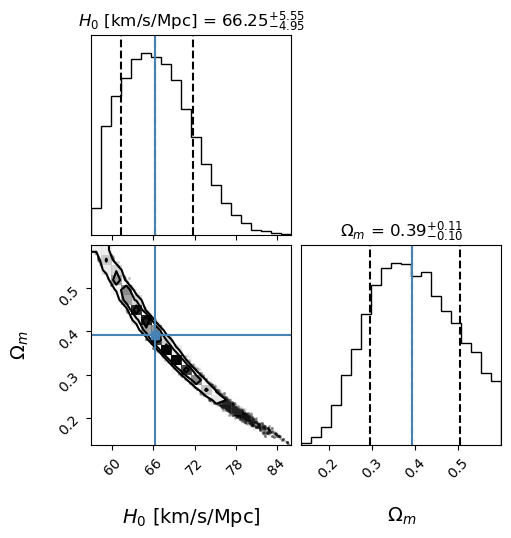

In [9]:
labels = [r"$H_0\ \mathrm{[km/s/Mpc]}$", r"$\Omega_m$"]

fig = corner.corner(
    flat_chain,
    labels=labels,
    show_titles=True,            
    title_fmt=".2f",             
    quantiles=[0.16, 0.5, 0.84], 
    title_kwargs={"fontsize": 12},
    label_kwargs={"fontsize": 14},
    truths=[best_H0, best_Om0],  
)

fig.savefig("corner_plot.png", dpi=150, bbox_inches="tight")
plt.show()


### Plot e visualizzazione delle catene

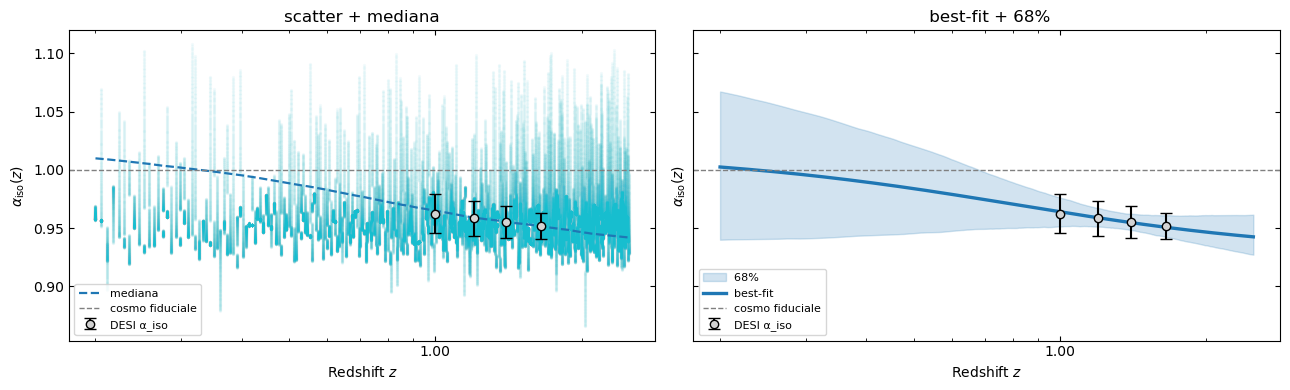

In [10]:
from matplotlib.ticker import ScalarFormatter

z_dense      = np.linspace(0.2, 2.5, 400)
Dv_fid_dense = dv_rd_model(z_dense, fid_cosmo)   
n_band   = min(800, flat_chain.shape[0])
idx_band = rng.choice(flat_chain.shape[0], size=n_band, replace=False)

alpha_mat = np.array([
    dv_rd_model(z_dense, build_cosmo(theta)) / Dv_fid_dense
    for theta in flat_chain[idx_band]
])  

alpha_med  = np.median(alpha_mat, axis=0)
alpha_low  = np.percentile(alpha_mat, 16, axis=0)
alpha_high = np.percentile(alpha_mat, 84, axis=0)

best_H0, best_Om0 = np.median(flat_chain, axis=0)
cosmo_best       = build_cosmo((best_H0, best_Om0))
alpha_best       = dv_rd_model(z_dense, cosmo_best) / Dv_fid_dense

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
scat_idx = rng.choice(n_band, size=min(300, n_band), replace=False)
axL.scatter(
    np.repeat(z_dense, scat_idx.size),
    alpha_mat[scat_idx].ravel(),
    s=2, alpha=0.04, color="tab:cyan"
)
axL.plot(z_dense, alpha_med, ls="--", lw=1.6,
         color="tab:blue", label="mediana")

axL.errorbar(z_data, alpha_data, yerr=alpha_sigma,
             fmt="o", ms=6, mfc="lightgray", mec="k",
             ecolor="k", capsize=4, label="DESI α_iso")
axL.axhline(1, ls="--", lw=1, color="grey", label="cosmo fiduciale")
axL.set_title("scatter + mediana")

axR.fill_between(z_dense, alpha_low, alpha_high,
                 color="tab:blue", alpha=0.20, label="68% ")
axR.plot(z_dense, alpha_best, lw=2.4, color="tab:blue",
         label=fr"best-fit ")

axR.errorbar(z_data, alpha_data, yerr=alpha_sigma,
             fmt="o", ms=6, mfc="lightgray", mec="k",
             ecolor="k", capsize=4, label="DESI α_iso")
axR.axhline(1, ls="--", lw=1, color="grey", label="cosmo fiduciale")
axR.set_title(" best-fit + 68%")

for ax in (axL, axR):
    ax.set_xscale("log")
    ax.set_xlabel("Redshift $z$")
    ax.set_ylabel(r"$\alpha_{\mathrm{iso}}(z)$")
    #ax.set_xlim(0.02, 2.5)
    #ax.set_ylim(0.9, 1.1)

    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.xaxis.get_major_formatter().set_scientific(False)
    ax.yaxis.set_major_formatter(ScalarFormatter())
    ax.yaxis.get_major_formatter().set_scientific(False)

    ax.tick_params(
        axis='both', which='both',
        direction='in', top=True, right=True,
        labeltop=False, labelright=False
    )
    ax.legend(fontsize=8, loc='lower left')

fig.tight_layout()
plt.show()
